# MorphPT vs DINOv3+LoRA — mouse Visium HD encoder comparison

Paired comparison across 4 tissues × 5 spatial-split layouts, identical training protocol.
The only varying factor is encoder initialization: MorphPT (DAPI/cell-type pretrained, Xenium)
vs DINOv3 ViT-B/16 (natural images, LVD-1689M). Both adapted with the same LoRA setup
(r=16, α=32, blocks 0,2,4,6,8,10,11, targets qkv/proj/mlp_fc1/mlp_fc2).

**Headline question:** does MorphPT's cell-type pretraining transfer to H&E gene expression
regression beyond what a generic visual encoder + LoRA can recover?

**Mechanism question:** does MorphPT show a larger variance-tier-over-coverage-tier gap than
DINOv3? A larger gap = stronger cell-type-discriminative prior.


## Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

plt.rcParams.update({
    'figure.dpi':         110,
    'savefig.dpi':        220,
    'font.size':          10,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titlelocation': 'left',
    'axes.titleweight':   'bold',
    'axes.titlesize':     11,
    'legend.frameon':     False,
})

## Configuration

In [2]:
TISSUES  = ['mouse_brain', 'mouse_intestine', 'mouse_kidney', 'mouse_embryo']
LAYOUTS  = ['seed23', 'seed123', 'seed456', 'seed789', 'seed1234']
ENCODERS = ['morphpt', 'dinov3_lora']
EXP_TAG  = {'morphpt': '', 'dinov3_lora': 'dinov3_lora'}

# Display labels
ENC_LABEL = {'morphpt': 'MorphPT', 'dinov3_lora': 'DINOv3+LoRA'}
ENC_COLOR = {'morphpt': '#C44E52', 'dinov3_lora': '#4C72B0'}

# Tier sizes
TIERS = [50, 100, 200, 300, 400, 500]

# Training metadata
N_TOP        = 500
SCALES_TAG   = '10.0x'
LOSS_SUFFIX  = 'mse'
BASE_SEED    = 42
SELECT_SEED  = 42

TISSUE_COLORS = {
    'mouse_brain':     '#4C72B0',
    'mouse_intestine': '#55A868',
    'mouse_kidney':    '#C44E52',
    'mouse_embryo':    '#8172B2',
}

def results_dir(encoder, tissue, layout):
    prefix = f'{EXP_TAG[encoder]}_' if EXP_TAG[encoder] else ''
    return PROJECT / 'experiments' / (
        f'{prefix}lora_probing_{tissue}_top{N_TOP}_multi_{layout}_'
        f'{SCALES_TAG}_{LOSS_SUFFIX}_seed{BASE_SEED}'
    )

def results_csv(encoder, tissue, layout):
    return results_dir(encoder, tissue, layout) / 'multi_lora_hybrid_results.csv'

def rank_csv(tissue, layout):
    return (PROJECT / f'cache_{tissue}' / 'splits' / layout /
            f'top{N_TOP}_variance_mincov0.1_train_{layout}_seed{SELECT_SEED}.csv')

## Load results — both encoders

For each (encoder, tissue, layout) load `multi_lora_hybrid_results.csv` and join with
the training-set variance rank + coverage from the gene-selection CSV.


In [3]:
rows, missing = [], []

for encoder in ENCODERS:
    for tissue in TISSUES:
        for layout in LAYOUTS:
            rcsv = results_csv(encoder, tissue, layout)
            kcsv = rank_csv(tissue, layout)

            if not rcsv.exists():
                missing.append((encoder, tissue, layout, 'result',  str(rcsv)))
                continue
            if not kcsv.exists():
                missing.append((encoder, tissue, layout, 'ranking', str(kcsv)))
                continue

            res    = pd.read_csv(rcsv)
            ranks  = pd.read_csv(kcsv)
            cov_cols = ['gene_idx', 'rank'] + (['coverage'] if 'coverage' in ranks.columns else [])
            merged = res.merge(ranks[cov_cols], on='gene_idx', how='left')

            test_col = next(c for c in merged.columns if c.startswith('test_pearson_s'))
            val_col  = next(c for c in merged.columns if c.startswith('val_pearson_s'))

            for _, r in merged.iterrows():
                rows.append({
                    'encoder':      encoder,
                    'tissue':       tissue,
                    'layout':       layout,
                    'gene_idx':     int(r['gene_idx']),
                    'gene_name':    r['gene_name'],
                    'rank':         int(r['rank']) if pd.notna(r['rank']) else None,
                    'coverage':     float(r['coverage']) if 'coverage' in merged.columns and pd.notna(r['coverage']) else np.nan,
                    'test_pearson': float(r[test_col]),
                    'val_pearson':  float(r[val_col]),
                })

df = pd.DataFrame(rows)
print(f'Loaded: {len(df):,} (encoder, tissue, layout, gene) rows from '
      f'{df.groupby(["encoder","tissue","layout"]).ngroups} runs')

if missing:
    print(f'\nMissing ({len(missing)}):')
    for m in missing:
        print(' ', *m[:4])

df.to_csv('mouse_encoder_comparison_results.csv', index=False)

Loaded: 20,000 (encoder, tissue, layout, gene) rows from 40 runs


## Per-run summary — both encoders

In [4]:
per_run = (df.groupby(['encoder', 'tissue', 'layout'])
             .agg(mean_test_r=('test_pearson', 'mean'),
                  median_test_r=('test_pearson', 'median'),
                  n_genes=('gene_idx', 'count'))
             .reset_index())

# Wide pivot: tissue rows, (encoder × layout) columns
pivot = (per_run.pivot_table(index='tissue', columns=['encoder', 'layout'],
                              values='mean_test_r')
                .reindex(TISSUES))
print('Mean test Pearson r per (tissue × encoder × layout):\n')
print(pivot.round(4))

# Per-tissue per-encoder summary
summary = (per_run.groupby(['encoder', 'tissue'])['mean_test_r']
                  .agg(['mean', 'std', 'min', 'max'])
                  .reset_index())
print('\nPer-tissue per-encoder summary (mean ± std across 5 layouts):\n')
print(summary.round(4).to_string(index=False))

Mean test Pearson r per (tissue × encoder × layout):

encoder         dinov3_lora                                  morphpt           \
layout              seed123 seed1234  seed23 seed456 seed789 seed123 seed1234   
tissue                                                                          
mouse_brain          0.2732   0.2123  0.2144  0.2780  0.2672  0.2773   0.2148   
mouse_intestine      0.2633   0.2617  0.2860  0.2767  0.2621  0.2633   0.2617   
mouse_kidney         0.3158   0.3318  0.3040  0.3228  0.3499  0.3156   0.3320   
mouse_embryo         0.2415   0.1322  0.2281  0.2440  0.1592  0.2434   0.1363   

encoder                                  
layout           seed23 seed456 seed789  
tissue                                   
mouse_brain      0.2145  0.2811  0.2779  
mouse_intestine  0.2852  0.2762  0.2614  
mouse_kidney     0.3048  0.3230  0.3517  
mouse_embryo     0.2300  0.2471  0.1628  

Per-tissue per-encoder summary (mean ± std across 5 layouts):

    encoder         

## Plot 1 — Headline: mean test r per tissue, by encoder

Grouped bars, MorphPT vs DINOv3+LoRA per tissue. Error bars = std across 5 layouts.
Dots = individual layouts. The encoder gap per tissue is the cross-modal transfer claim.

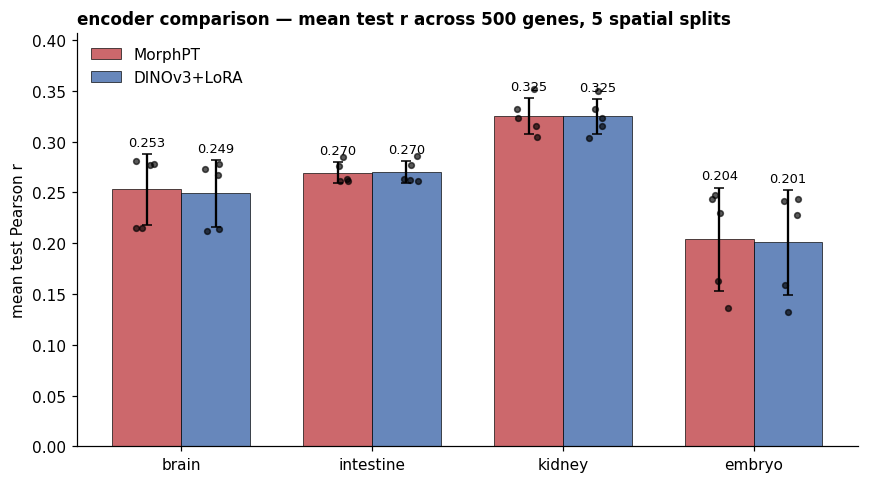

In [5]:
agg = (per_run.groupby(['tissue', 'encoder'])['mean_test_r']
              .agg(['mean', 'std', list])
              .reset_index())

fig, ax = plt.subplots(figsize=(8, 4.5))
xs   = np.arange(len(TISSUES))
w    = 0.36

rng = np.random.default_rng(0)
for j, encoder in enumerate(ENCODERS):
    sub = agg[agg['encoder'] == encoder].set_index('tissue').reindex(TISSUES)
    offset = (j - 0.5) * w
    ax.bar(xs + offset, sub['mean'], width=w,
           yerr=sub['std'], capsize=3,
           color=ENC_COLOR[encoder], edgecolor='black', linewidth=0.5,
           alpha=0.85, label=ENC_LABEL[encoder])
    # Overlay layout dots
    for i, vals in enumerate(sub['list']):
        if not isinstance(vals, list):
            continue
        xj = (i + offset) + rng.uniform(-0.06, 0.06, len(vals))
        ax.scatter(xj, vals, s=14, color='black', alpha=0.65, zorder=3)
    # Value annotations
    for i, (m, s) in enumerate(zip(sub['mean'], sub['std'])):
        if pd.notna(m):
            ax.text(i + offset, m + (s if pd.notna(s) else 0) + 0.005,
                    f'{m:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('mean test Pearson r')
ax.set_title('encoder comparison — mean test r across 500 genes, 5 spatial splits')
ax.legend(loc='upper left')
ax.set_ylim(0, agg.groupby('tissue')['mean'].max().max() * 1.25)
plt.tight_layout()
plt.savefig('plot_encoder_comparison_bars.pdf', bbox_inches='tight')
plt.show()

## Plot 1b — Per-tissue Δr (MorphPT − DINOv3) with paired Wilcoxon

For each tissue, MorphPT vs DINOv3 across the 5 *matched* layouts gives 5 paired samples.
Wilcoxon signed-rank test (one-sided, MorphPT > DINOv3). Pooled test uses all 20 pairs.

In [6]:
# Compute paired deltas per (tissue, layout)
wide = per_run.pivot_table(index=['tissue', 'layout'],
                            columns='encoder', values='mean_test_r').reset_index()
wide['delta'] = wide['morphpt'] - wide['dinov3_lora']

# Per-tissue stats
delta_stats = []
for tissue in TISSUES:
    sub = wide[wide['tissue'] == tissue].dropna(subset=['morphpt', 'dinov3_lora'])
    deltas = sub['delta'].values
    if len(deltas) >= 2:
        w_stat, p_one = stats.wilcoxon(deltas, alternative='greater',
                                        zero_method='wilcox', mode='exact')
    else:
        w_stat, p_one = np.nan, np.nan
    delta_stats.append({
        'tissue':      tissue,
        'n_pairs':     len(deltas),
        'mean_delta':  deltas.mean() if len(deltas) else np.nan,
        'std_delta':   deltas.std()  if len(deltas) else np.nan,
        'wilcoxon_W':  w_stat,
        'p_one_sided': p_one,
    })
delta_stats_df = pd.DataFrame(delta_stats)
print('Per-tissue paired test (MorphPT − DINOv3, one-sided Wilcoxon):\n')
print(delta_stats_df.round(4).to_string(index=False))

# Pooled across all 20 pairs
pooled_deltas = wide['delta'].dropna().values
w_pool, p_pool = stats.wilcoxon(pooled_deltas, alternative='greater',
                                 zero_method='wilcox', mode='exact')
print(f'\nPooled across all {len(pooled_deltas)} (tissue, layout) pairs:')
print(f'  mean Δr = {pooled_deltas.mean():+.4f}')
print(f'  Wilcoxon W = {w_pool}, one-sided p = {p_pool:.3g}')

Per-tissue paired test (MorphPT − DINOv3, one-sided Wilcoxon):

         tissue  n_pairs  mean_delta  std_delta  wilcoxon_W  p_one_sided
    mouse_brain        5      0.0041     0.0035        15.0       0.0312
mouse_intestine        5     -0.0004     0.0003         2.0       0.9375
   mouse_kidney        5      0.0006     0.0007        14.0       0.0625
   mouse_embryo        5      0.0029     0.0009        15.0       0.0312

Pooled across all 20 (tissue, layout) pairs:
  mean Δr = +0.0018
  Wilcoxon W = 181.0, one-sided p = 0.00158


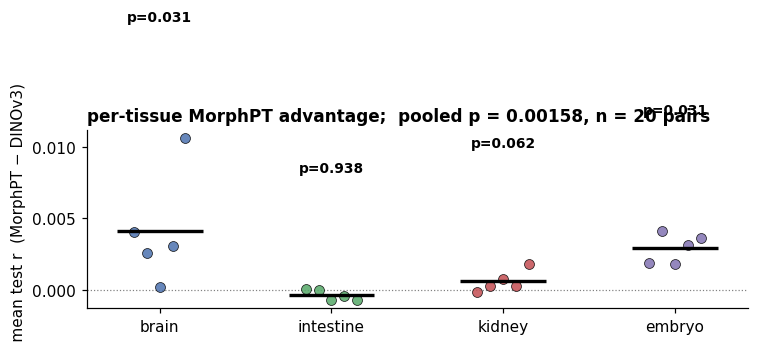

In [7]:
# Plot Δr per tissue with dot strip + p-value annotation
fig, ax = plt.subplots(figsize=(7, 4.2))
xs = np.arange(len(TISSUES))

for i, tissue in enumerate(TISSUES):
    sub = wide[wide['tissue'] == tissue].dropna(subset=['delta'])
    deltas = sub['delta'].values
    if len(deltas) == 0:
        continue
    xj = i + np.linspace(-0.15, 0.15, len(deltas))
    ax.scatter(xj, deltas, s=42, color=TISSUE_COLORS[tissue],
               edgecolor='black', linewidth=0.5, alpha=0.85, zorder=3)
    m = deltas.mean()
    ax.hlines(m, i - 0.25, i + 0.25, color='black', linewidth=2.2, zorder=4)

    p = delta_stats_df.set_index('tissue').loc[tissue, 'p_one_sided']
    p_text = f'p={p:.3f}' if pd.notna(p) and p >= 0.001 else 'p<0.001'
    y_top = max(deltas.max(), m) + 0.005
    ax.text(i, y_top + 0.003, p_text, ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xticks(xs)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('Δ mean test r  (MorphPT − DINOv3)')
ax.set_title(f'per-tissue MorphPT advantage;  pooled p = {p_pool:.3g}, n = {len(pooled_deltas)} pairs')
plt.tight_layout()
plt.savefig('plot_encoder_delta.pdf', bbox_inches='tight')
plt.show()

## Tier computations — variance / coverage / performance × encoder

For each (encoder, tissue, layout) compute mean test r over the top-N genes ranked by:
- **variance** (a-priori, train-set variance — the realistic selection rule, no leakage)
- **coverage** (a-priori, fraction of cells expressing — abundance control)
- **performance** (post-hoc, ranked by test_pearson — oracle ceiling)

In [8]:
def compute_tiers(df_in, rank_col):
    rows = []
    for (encoder, tissue, layout), sub in df_in.groupby(['encoder', 'tissue', 'layout']):
        if rank_col == 'rank':
            sub_sorted = sub.sort_values('rank', ascending=True)
        elif rank_col == 'test_pearson':
            sub_sorted = sub.sort_values('test_pearson', ascending=False)
        elif rank_col == 'coverage':
            sub_sorted = sub.dropna(subset=['coverage']).sort_values('coverage', ascending=False)
        else:
            raise ValueError(rank_col)
        for tier in TIERS:
            top = sub_sorted.head(tier)
            rows.append({
                'encoder':     encoder,
                'tissue':      tissue,
                'layout':      layout,
                'tier':        tier,
                'mean_test_r': top['test_pearson'].mean(),
                'n_genes':     len(top),
            })
    return pd.DataFrame(rows)

var_tier  = compute_tiers(df, 'rank')
cov_tier  = compute_tiers(df, 'coverage')
perf_tier = compute_tiers(df, 'test_pearson')

def aggregate_tiers(tdf):
    return (tdf.groupby(['encoder', 'tissue', 'tier'])
               .agg(mean=('mean_test_r', 'mean'),
                    std =('mean_test_r', 'std'))
               .reset_index())

var_agg  = aggregate_tiers(var_tier)
cov_agg  = aggregate_tiers(cov_tier)
perf_agg = aggregate_tiers(perf_tier)

print('Variance-tier means at top-50 (encoder × tissue):\n')
print(var_agg[var_agg['tier'] == 50]
        .pivot(index='tissue', columns='encoder', values='mean')[ENCODERS]
        .reindex(TISSUES).round(3))

Variance-tier means at top-50 (encoder × tissue):

encoder          morphpt  dinov3_lora
tissue                               
mouse_brain        0.355        0.348
mouse_intestine    0.578        0.580
mouse_kidney       0.615        0.615
mouse_embryo       0.355        0.354


## Plot 2 — Variance-tier curves: MorphPT vs DINOv3 (4-panel)

One panel per tissue. Variance-ranked tier curve for both encoders.
Same shape (monotonic decrease with N) for both; if MorphPT carries a cell-type prior,
its top-tier advantage should be larger than DINOv3's.

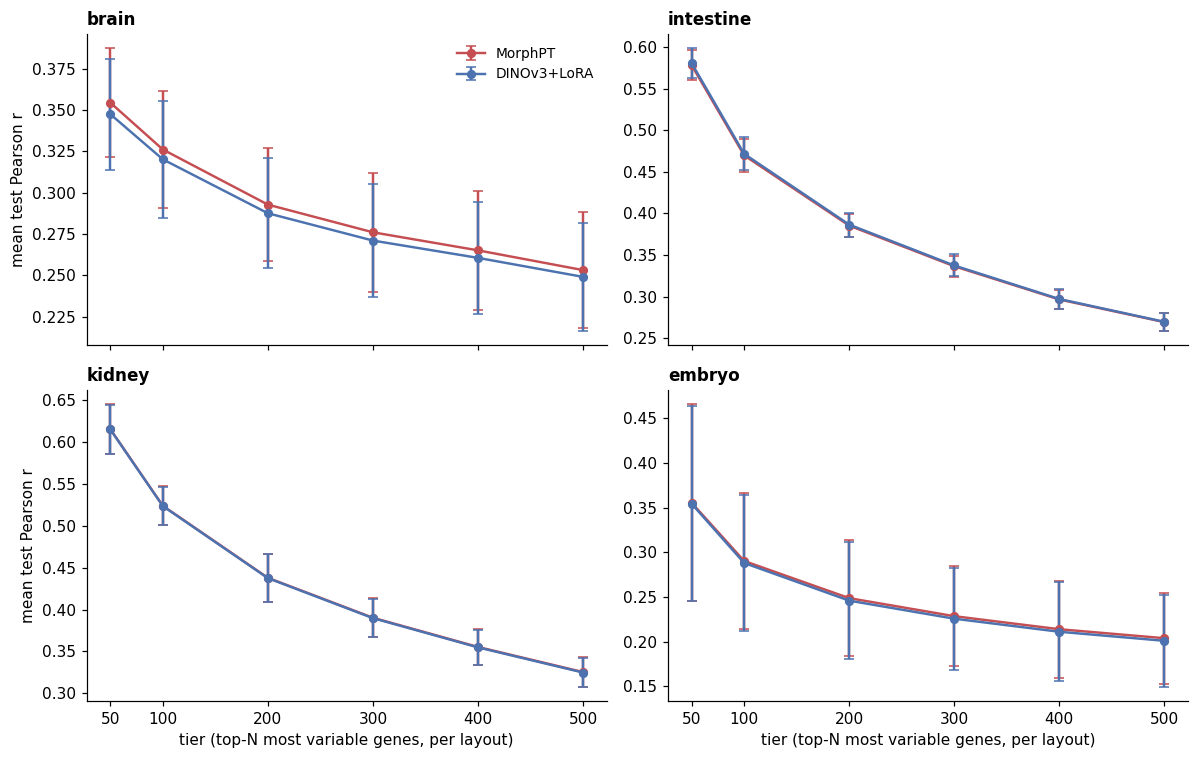

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

for ax, tissue in zip(axes.flat, TISSUES):
    for encoder in ENCODERS:
        sub = var_agg[(var_agg['encoder'] == encoder) &
                      (var_agg['tissue']  == tissue)].sort_values('tier')
        ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                    marker='o', markersize=5, capsize=3, linewidth=1.6,
                    color=ENC_COLOR[encoder], label=ENC_LABEL[encoder])
    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)

axes[0, 0].legend(loc='upper right', fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel('tier (top-N most variable genes, per layout)')
for ax in axes[:, 0]:
    ax.set_ylabel('mean test Pearson r')

plt.tight_layout()
plt.savefig('plot_variance_tier_by_encoder.pdf', bbox_inches='tight')
plt.show()

## Plot 3 — Variance-over-coverage gap: MorphPT vs DINOv3

Mechanism plot. For each (encoder, tissue, tier) compute Δ = variance-tier r − coverage-tier r.
A larger Δ means the encoder predicts cell-type-discriminative (high-variance) genes
disproportionately better than abundance-driven (high-coverage) genes — the signature
of a cell-type-aware representation.

If MorphPT's Δ > DINOv3's Δ, the pretraining objective specifically transferred a cell-type prior.

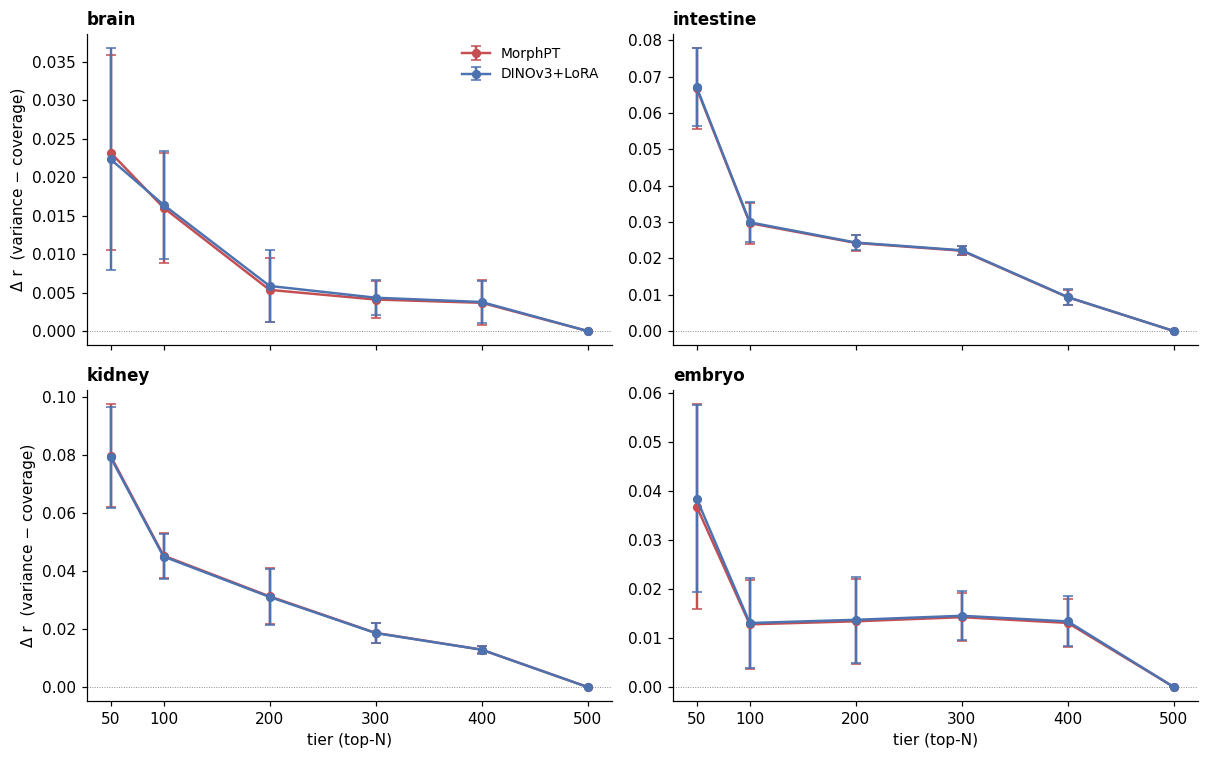

Variance-over-coverage gap, MorphPT vs DINOv3 at top-50:
  paired n = 20,  mean Δgap = -0.0001
  Wilcoxon W = 112.0, one-sided p = 0.406


In [10]:
gap_rows = []
for (encoder, tissue, layout), _ in df.groupby(['encoder', 'tissue', 'layout']):
    v = var_tier[(var_tier['encoder'] == encoder) &
                  (var_tier['tissue']  == tissue)  &
                  (var_tier['layout']  == layout)].set_index('tier')['mean_test_r']
    c = cov_tier[(cov_tier['encoder'] == encoder) &
                  (cov_tier['tissue']  == tissue)  &
                  (cov_tier['layout']  == layout)].set_index('tier')['mean_test_r']
    for tier in TIERS:
        if tier in v.index and tier in c.index:
            gap_rows.append({
                'encoder': encoder, 'tissue': tissue, 'layout': layout,
                'tier':    tier,    'gap':    v[tier] - c[tier],
            })
gap_df = pd.DataFrame(gap_rows)
gap_agg = (gap_df.groupby(['encoder', 'tissue', 'tier'])
                  .agg(mean=('gap', 'mean'), std=('gap', 'std'))
                  .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, tissue in zip(axes.flat, TISSUES):
    for encoder in ENCODERS:
        sub = gap_agg[(gap_agg['encoder'] == encoder) &
                       (gap_agg['tissue']  == tissue)].sort_values('tier')
        ax.errorbar(sub['tier'], sub['mean'], yerr=sub['std'],
                    marker='o', markersize=5, capsize=3, linewidth=1.6,
                    color=ENC_COLOR[encoder], label=ENC_LABEL[encoder])
    ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xticks(TIERS)

axes[0, 0].legend(loc='upper right', fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel('tier (top-N)')
for ax in axes[:, 0]:
    ax.set_ylabel('Δ r  (variance − coverage)')

plt.tight_layout()
plt.savefig('plot_variance_coverage_gap_by_encoder.pdf', bbox_inches='tight')
plt.show()

# Stats: at top-50, paired across (tissue, layout)
gap_wide = (gap_df[gap_df['tier'] == 50]
              .pivot_table(index=['tissue', 'layout'], columns='encoder', values='gap')
              .reset_index())
gap_wide['gap_diff'] = gap_wide['morphpt'] - gap_wide['dinov3_lora']
paired = gap_wide['gap_diff'].dropna().values
if len(paired) >= 2:
    w_gap, p_gap = stats.wilcoxon(paired, alternative='greater', mode='exact')
    print(f'Variance-over-coverage gap, MorphPT vs DINOv3 at top-50:')
    print(f'  paired n = {len(paired)},  mean Δgap = {paired.mean():+.4f}')
    print(f'  Wilcoxon W = {w_gap}, one-sided p = {p_gap:.3g}')

## Plot 4 — Variance / coverage / performance, per encoder

3-ranking comparison plot split by encoder so you can verify the
variance > coverage ordering holds for both. Two figures, one per encoder.

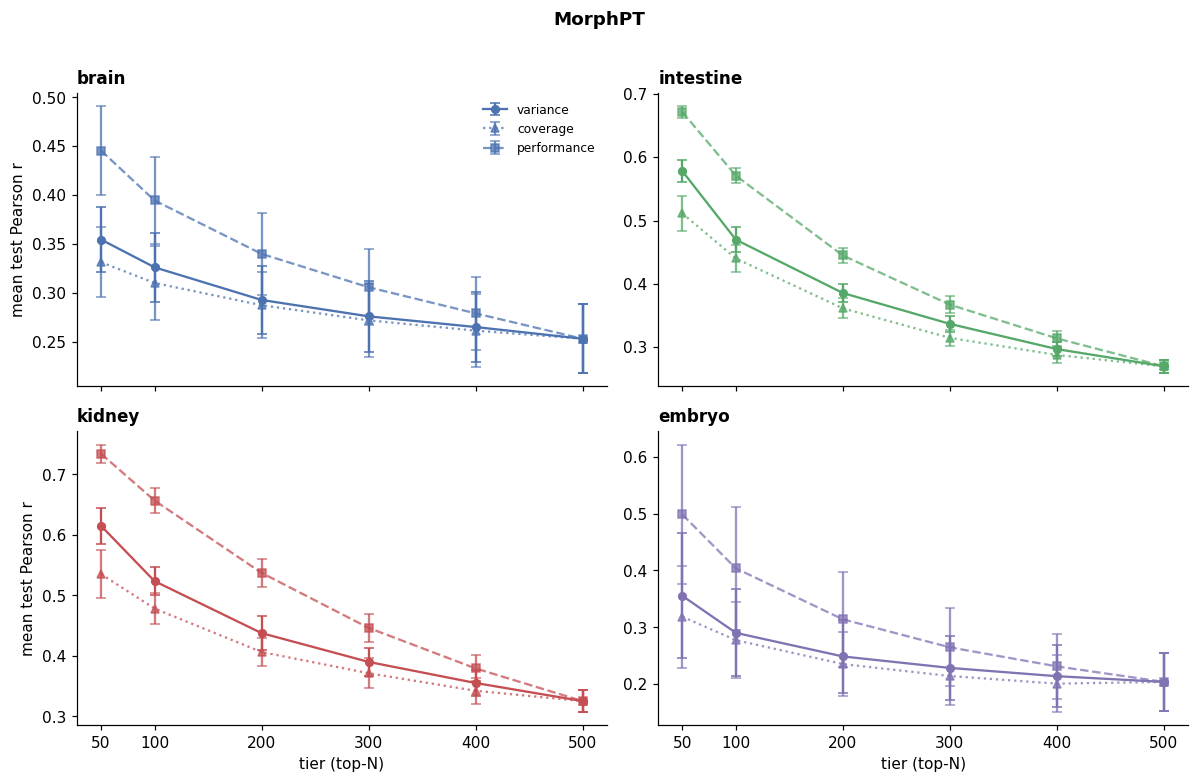

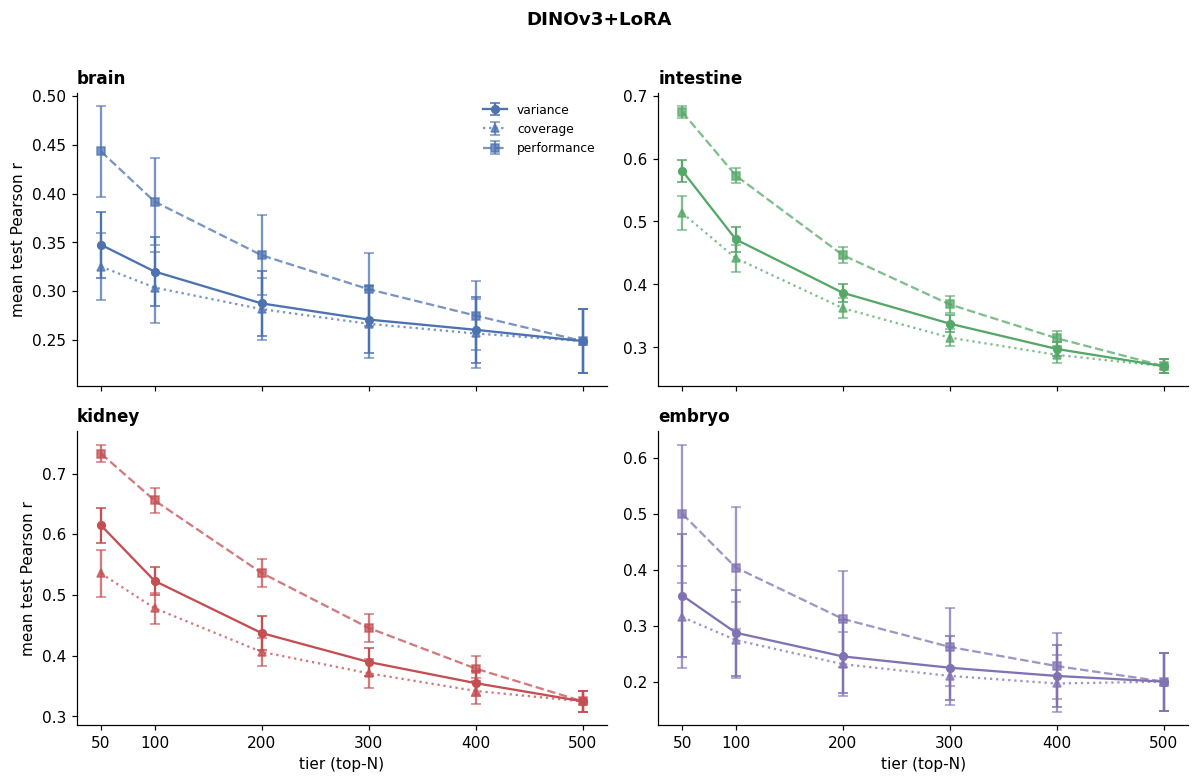

In [11]:
for encoder in ENCODERS:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    for ax, tissue in zip(axes.flat, TISSUES):
        color = TISSUE_COLORS[tissue]
        v = var_agg[(var_agg['encoder'] == encoder) & (var_agg['tissue'] == tissue)].sort_values('tier')
        c = cov_agg[(cov_agg['encoder'] == encoder) & (cov_agg['tissue'] == tissue)].sort_values('tier')
        p = perf_agg[(perf_agg['encoder'] == encoder) & (perf_agg['tissue'] == tissue)].sort_values('tier')

        ax.errorbar(v['tier'], v['mean'], yerr=v['std'], marker='o', markersize=5,
                    capsize=3, linewidth=1.5, color=color, linestyle='-',  label='variance')
        ax.errorbar(c['tier'], c['mean'], yerr=c['std'], marker='^', markersize=5,
                    capsize=3, linewidth=1.5, color=color, linestyle=':',  alpha=0.75, label='coverage')
        ax.errorbar(p['tier'], p['mean'], yerr=p['std'], marker='s', markersize=5,
                    capsize=3, linewidth=1.5, color=color, linestyle='--', alpha=0.75, label='performance')

        ax.set_title(tissue.replace('mouse_', ''))
        ax.set_xticks(TIERS)

    axes[0, 0].legend(loc='upper right', fontsize=8)
    for ax in axes[-1, :]:
        ax.set_xlabel('tier (top-N)')
    for ax in axes[:, 0]:
        ax.set_ylabel('mean test Pearson r')

    plt.suptitle(f'{ENC_LABEL[encoder]}', y=1.01, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plot_tier_3way_{encoder}.pdf', bbox_inches='tight')
    plt.show()

## Plot 5 — Per-layout strip, by encoder

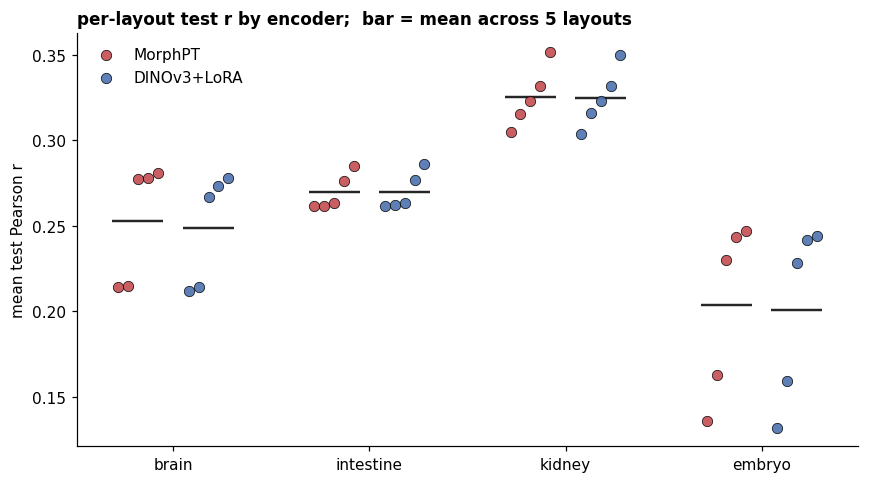

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xs_base = np.arange(len(TISSUES))
w = 0.36

for j, encoder in enumerate(ENCODERS):
    offset = (j - 0.5) * w
    for i, tissue in enumerate(TISSUES):
        sub = per_run[(per_run['encoder'] == encoder) &
                       (per_run['tissue']  == tissue)].sort_values('mean_test_r')
        vals = sub['mean_test_r'].values
        if len(vals) == 0:
            continue
        xj = (i + offset) + np.linspace(-0.10, 0.10, len(vals))
        ax.scatter(xj, vals, s=46, color=ENC_COLOR[encoder],
                   edgecolor='black', linewidth=0.5, alpha=0.9,
                   zorder=3, label=ENC_LABEL[encoder] if i == 0 else None)
        ax.hlines(vals.mean(), i + offset - 0.13, i + offset + 0.13,
                  color='black', linewidth=1.6, alpha=0.85)

ax.set_xticks(xs_base)
ax.set_xticklabels([t.replace('mouse_', '') for t in TISSUES])
ax.set_ylabel('mean test Pearson r')
ax.set_title('per-layout test r by encoder;  bar = mean across 5 layouts')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('plot_per_layout_strip_by_encoder.pdf', bbox_inches='tight')
plt.show()

## Plot 6 — Per-cell transcriptional fidelity by encoder

For each tissue, take the best-mean layout per encoder, compute per-cell Pearson r
across the 500 genes. Two histograms per tissue (one per encoder).

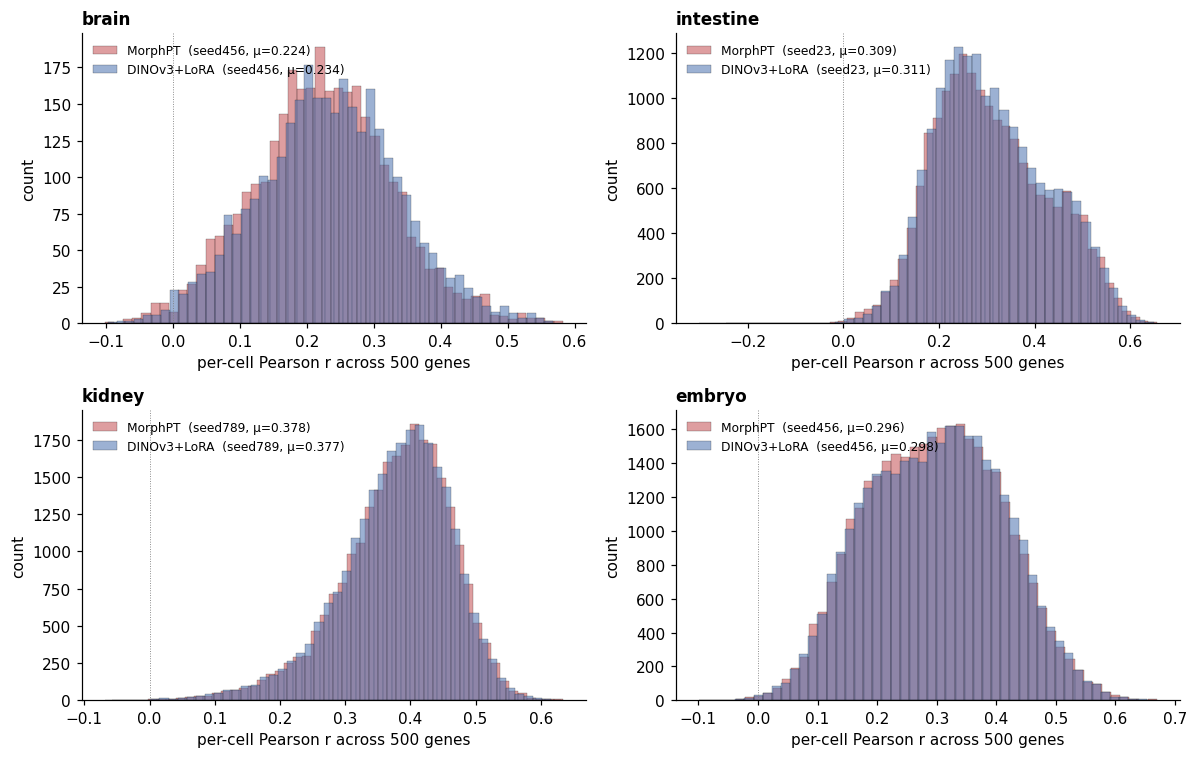

In [13]:
best_layout = (per_run.sort_values(['encoder', 'tissue', 'mean_test_r'],
                                    ascending=[True, True, False])
                       .groupby(['encoder', 'tissue']).first()['layout']
                       .to_dict())

def load_test_arrays(encoder, tissue, layout):
    rdir = results_dir(encoder, tissue, layout)
    return (np.load(rdir / f'test_y_pred_seed_{BASE_SEED}.npy'),
            np.load(rdir / f'test_y_true_seed_{BASE_SEED}.npy'))

def per_cell_r(y_pred, y_true):
    pm = y_pred - y_pred.mean(axis=1, keepdims=True)
    tm = y_true - y_true.mean(axis=1, keepdims=True)
    num = (pm * tm).sum(axis=1)
    den = np.sqrt((pm**2).sum(axis=1) * (tm**2).sum(axis=1)) + 1e-8
    r = num / den
    return r[np.isfinite(r)]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, tissue in zip(axes.flat, TISSUES):
    for encoder in ENCODERS:
        layout = best_layout.get((encoder, tissue))
        if layout is None:
            continue
        try:
            yp, yt = load_test_arrays(encoder, tissue, layout)
        except FileNotFoundError:
            continue
        r = per_cell_r(yp, yt)
        ax.hist(r, bins=50, alpha=0.55, color=ENC_COLOR[encoder],
                edgecolor='black', linewidth=0.25,
                label=f'{ENC_LABEL[encoder]}  ({layout}, μ={r.mean():.3f})')
    ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')
    ax.set_title(tissue.replace('mouse_', ''))
    ax.set_xlabel('per-cell Pearson r across 500 genes')
    ax.set_ylabel('count')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('plot_per_cell_fidelity_by_encoder.pdf', bbox_inches='tight')
plt.show()

## Statistical summary

Tidy table: per-tissue Δr, Wilcoxon p, plus pooled test. Drop-in for a supplementary table.

In [14]:
summary_rows = []
for tissue in TISSUES:
    sub = wide[wide['tissue'] == tissue].dropna(subset=['morphpt', 'dinov3_lora'])
    s = delta_stats_df.set_index('tissue').loc[tissue]
    summary_rows.append({
        'tissue':       tissue,
        'morphpt_mean': sub['morphpt'].mean(),
        'morphpt_std':  sub['morphpt'].std(),
        'dinov3_mean':  sub['dinov3_lora'].mean(),
        'dinov3_std':   sub['dinov3_lora'].std(),
        'delta_mean':   s['mean_delta'],
        'delta_std':    s['std_delta'],
        'wilcoxon_p':   s['p_one_sided'],
    })
summary_table = pd.DataFrame(summary_rows)

pooled_row = pd.DataFrame([{
    'tissue':       'POOLED',
    'morphpt_mean': wide['morphpt'].mean(),
    'morphpt_std':  wide['morphpt'].std(),
    'dinov3_mean':  wide['dinov3_lora'].mean(),
    'dinov3_std':   wide['dinov3_lora'].std(),
    'delta_mean':   wide['delta'].mean(),
    'delta_std':    wide['delta'].std(),
    'wilcoxon_p':   p_pool,
}])
summary_table = pd.concat([summary_table, pooled_row], ignore_index=True)
print('Encoder comparison summary:\n')
print(summary_table.round(4).to_string(index=False))

summary_table.to_csv('encoder_comparison_summary.csv', index=False)
print('\nSaved → encoder_comparison_summary.csv')

Encoder comparison summary:

         tissue  morphpt_mean  morphpt_std  dinov3_mean  dinov3_std  delta_mean  delta_std  wilcoxon_p
    mouse_brain        0.2531       0.0351       0.2490      0.0328      0.0041     0.0035      0.0312
mouse_intestine        0.2696       0.0107       0.2700      0.0109     -0.0004     0.0003      0.9375
   mouse_kidney        0.3254       0.0178       0.3249      0.0173      0.0006     0.0007      0.0625
   mouse_embryo        0.2039       0.0509       0.2010      0.0517      0.0029     0.0009      0.0312
         POOLED        0.2630       0.0536       0.2612      0.0544      0.0018     0.0026      0.0016

Saved → encoder_comparison_summary.csv


## Files saved

- `mouse_encoder_comparison_results.csv` — long-format (encoder, tissue, layout, gene, rank, coverage, val_r, test_r)
- `encoder_comparison_summary.csv` — per-tissue + pooled paired stats
- `plot_encoder_comparison_bars.pdf` — **headline**: grouped bars, MorphPT vs DINOv3 per tissue
- `plot_encoder_delta.pdf` — per-tissue Δr with Wilcoxon p-values
- `plot_variance_tier_by_encoder.pdf` — variance-tier curves overlay (4-panel)
- `plot_variance_coverage_gap_by_encoder.pdf` — **mechanism**: variance-over-coverage gap, by encoder
- `plot_tier_3way_morphpt.pdf`, `plot_tier_3way_dinov3_lora.pdf` — full 3-ranking per encoder
- `plot_per_layout_strip_by_encoder.pdf` — per-layout dots, both encoders
- `plot_per_cell_fidelity_by_encoder.pdf` — per-cell Pearson r distributions per encoder
